# 02 — EDA for Recommender System
## FAR-Trans · Pre-design analysis

**Цели:**
- Провалидировать архитектурные решения до написания кода
- Понять реальное распределение данных для задачи CF (не propensity)
- Проверить все критические допущения: cold-start, sparsity, risk-filter, repeat-buy, temporal window
- Определить пороги и параметры модели на основе данных, а не умозрительно

**Литературная база:**
- Hu, Koren & Volinsky (2008) — ALS для implicit feedback, confidence weighting
- Rendle et al. (2009) — BPR loss, cold-start
- He et al. (2017) — NCF, LOO evaluation protocol
- Burke (2002) — Hybrid Recommender Systems, learned weights
- Sanz-Cruzado et al. (2024) — FAR-Trans dataset paper (исходный датасет)

## 0. Импорт и настройки



In [1]:
import sys, warnings, json
sys.path.insert(0, "../../propensity_model/src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

from data_loader import load_transactions, load_customers, load_assets, get_customer_profile_at
from config import RISK_LEVEL_CANONICAL, INVESTMENT_CAPACITY_CANONICAL

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 10,
})

BLUE   = "#2563EB"
RED    = "#DC2626"
GREEN  = "#16A34A"
GREY   = "#94A3B8"
ORANGE = "#EA580C"
PURPLE = "#7C3AED"

EDA_DIR = Path("../outputs/eda_recommender")
EDA_DIR.mkdir(parents=True, exist_ok=True)

# Параметры временного сплита (зеркало propensity)
TRAIN_END  = pd.Timestamp("2021-01-01")
VALID_END  = pd.Timestamp("2021-10-01")
SNAPSHOT_DATE = pd.Timestamp("2021-01-01")  # «срез» для симуляции inference

print("Настройки загружены")

Настройки загружены


## 1. Загрузка данных



In [2]:
tx_raw   = load_transactions()
customers = load_customers()
assets    = load_assets()

# Только Buy-транзакции (Sell — выход из позиции, не сигнал предпочтения для CF)
# Hu et al. (2008): для implicit feedback используются только positive interactions
tx = tx_raw[tx_raw["transactionType"] == "Buy"].copy()

print(f"\nВсего транзакций (raw):          {len(tx_raw):>10,}")
print(f"Buy-транзакций (для CF matrix):  {len(tx):>10,}")
print(f"Sell-транзакций (исключены):     {len(tx_raw) - len(tx):>10,}")
print(f"Уникальных клиентов:             {tx['customerID'].nunique():>10,}")
print(f"Уникальных ISIN в покупках:      {tx['ISIN'].nunique():>10,}")
print(f"Всего ISIN в asset_info:         {assets['ISIN'].nunique():>10,}")
print(f"\nПериод транзакций: {tx['timestamp'].min().date()} → {tx['timestamp'].max().date()}")


Всего транзакций (raw):             359,128
Buy-транзакций (для CF matrix):     213,639
Sell-транзакций (исключены):        145,489
Уникальных клиентов:                 28,147
Уникальных ISIN в покупках:             320
Всего ISIN в asset_info:                806

Период транзакций: 2018-01-02 → 2022-11-30


## 2. Анализ synthetic transactions

Транзакции с transactionID < 0: 38,019 (10.6% от всех)
  Buy синтетических: 38,019
  Sell синтетических: 0


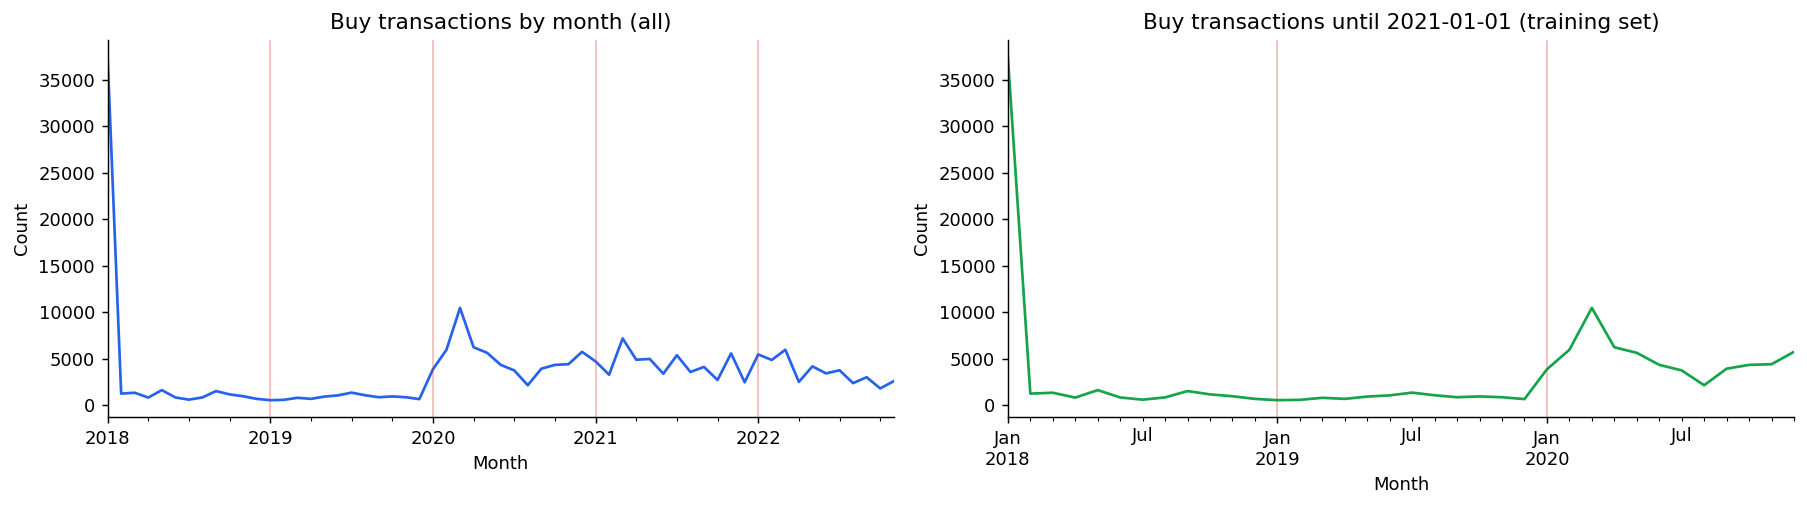


Месяца с аномально высоким числом транзакций (z > 2.5):
month
2018-01    37443
Freq: M


In [3]:
# 2.1 Синтетические транзакции (transactionID < 0)
synth_negative = tx_raw[tx_raw["transactionID"] < 0]
print(f"Транзакции с transactionID < 0: {len(synth_negative):,} ({len(synth_negative)/len(tx_raw)*100:.1f}% от всех)")
print(f"  Buy синтетических: {(synth_negative['transactionType'] == 'Buy').sum():,}")
print(f"  Sell синтетических: {(synth_negative['transactionType'] == 'Sell').sum():,}")

# 2.2 Проверка: аномальные пики по месяцам
tx['month'] = tx['timestamp'].dt.to_period('M')
monthly = tx.groupby('month').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Все Buy по месяцам
ax = axes[0]
monthly.plot(ax=ax, color=BLUE, linewidth=1.5)
ax.set_title("Buy transactions by month (all)")
ax.set_xlabel("Month")
ax.set_ylabel("Count")
# Подсветить январи
for period in monthly.index:
    if period.month == 1:
        ax.axvline(period.ordinal, color=RED, alpha=0.3, linewidth=1)

# До TRAIN_END (матрица для обучения)
ax2 = axes[1]
tx_train = tx[tx['timestamp'] < TRAIN_END]
tx_train.groupby('month').size().plot(ax=ax2, color=GREEN, linewidth=1.5)
ax2.set_title(f"Buy transactions until {TRAIN_END.date()} (training set)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Count")
for period in tx_train.groupby('month').size().index:
    if period.month == 1:
        ax2.axvline(period.ordinal, color=RED, alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig(EDA_DIR / "synthetic_monthly_check.png", bbox_inches="tight")
plt.show()

# Z-score аномалий
z_scores = np.abs(stats.zscore(monthly.values))
anomalous = monthly[z_scores > 2.5]
print(f"\nМесяца с аномально высоким числом транзакций (z > 2.5):")
print(anomalous.to_string())

## 3. User-Item матрица: разреженность

In [4]:
# 3.1 Глобальные числа user-item матрицы
tx_train = tx[tx['timestamp'] < TRAIN_END].copy()

n_users = tx_train['customerID'].nunique()
n_items = tx_train['ISIN'].nunique()
n_interactions = tx_train.groupby(['customerID', 'ISIN']).size().reset_index(name='count')
n_pairs = len(n_interactions)

density = n_pairs / (n_users * n_items)

print("═" * 55)
print("  USER-ITEM MATRIX — глобальная статистика")
print("═" * 55)
print(f"  Уникальных клиентов (строк):   {n_users:>8,}")
print(f"  Уникальных ISIN (столбцов):    {n_items:>8,}")
print(f"  Ненулевых ячеек (пар u-i):     {n_pairs:>8,}")
print(f"  Плотность матрицы:             {density:>8.4%}")
print(f"  Среднее покупок на клиента:    {n_pairs/n_users:>8.2f}")
print(f"  Среднее покупателей на ISIN:   {n_pairs/n_items:>8.2f}")

# 3.2 Плотность при разных временных окнах
print("\n  Плотность при разных INTERACTION_WINDOW_DAYS:")
print(f"  {'Window':>10} | {'Users':>8} | {'Items':>7} | {'Pairs':>9} | {'Density':>9}")
print("  " + "-" * 50)
for window in [180, 365, 548, 730, None]:
    label = f"{window}d" if window else "all"
    if window:
        cutoff = TRAIN_END - pd.Timedelta(days=window)
        sub = tx_train[tx_train['timestamp'] >= cutoff]
    else:
        sub = tx_train
    u = sub['customerID'].nunique()
    i = sub['ISIN'].nunique()
    p = sub.groupby(['customerID', 'ISIN']).size().count()
    d = p / (u * i) if u * i > 0 else 0
    print(f"  {label:>10} | {u:>8,} | {i:>7,} | {p:>9,} | {d:>9.4%}")

═══════════════════════════════════════════════════════
  USER-ITEM MATRIX — глобальная статистика
═══════════════════════════════════════════════════════
  Уникальных клиентов (строк):     22,905
  Уникальных ISIN (столбцов):         279
  Ненулевых ячеек (пар u-i):       58,872
  Плотность матрицы:              0.9212%
  Среднее покупок на клиента:        2.57
  Среднее покупателей на ISIN:     211.01

  Плотность при разных INTERACTION_WINDOW_DAYS:
      Window |    Users |   Items |     Pairs |   Density
  --------------------------------------------------
        180d |    4,087 |     172 |    11,342 |   1.6135%
        365d |    6,915 |     199 |    23,101 |   1.6787%
        548d |    7,306 |     216 |    24,768 |   1.5695%
        730d |    7,464 |     228 |    25,780 |   1.5149%
         all |   22,905 |     279 |    58,872 |   0.9212%


## 4. Распределение покупок на клиента — cold-start реальность

Симулируем hot_customers как клиентов с `days_since_last_buy ≤ 90` на дату TRAIN_END (proxy для warm/dormant).



In [5]:
# 4.1 Для каждого клиента: last buy date и кол-во уникальных ISIN куплено
customer_stats = tx_train.groupby('customerID').agg(
    n_buys=('ISIN', 'count'),
    n_unique_isin=('ISIN', 'nunique'),
    last_buy=('timestamp', 'max'),
    first_buy=('timestamp', 'min'),
).reset_index()

customer_stats['days_since_buy'] = (TRAIN_END - customer_stats['last_buy']).dt.days
customer_stats['tenure_days'] = (TRAIN_END - customer_stats['first_buy']).dt.days

# Все клиенты из training set
all_clients = customer_stats

# Proxy hot_customers: активные ≤60d или в зоне reactivation (60-180d) на дату среза
# Соответствует критерию propensity модели: warm ≤ 90d (personal threshold)
hot_proxy_warm = customer_stats[customer_stats['days_since_buy'] <= 60]
hot_proxy_extended = customer_stats[customer_stats['days_since_buy'] <= 180]

print("═" * 65)
print("  РАСПРЕДЕЛЕНИЕ ПОКУПОК: ВСЕ vs HOT КЛИЕНТЫ")
print("═" * 65)

for label, subset in [("Все клиенты (train)", all_clients),
                       ("Warm proxy (≤60d)", hot_proxy_warm),
                       ("Extended proxy (≤180d)", hot_proxy_extended)]:
    print(f"\n  {label}: n={len(subset):,}")
    print(f"    Медиана n_buys:       {subset['n_buys'].median():.0f}")
    print(f"    Медиана n_unique_isin:{subset['n_unique_isin'].median():.0f}")
    for thr in [2, 3, 5, 10]:
        pct = (subset['n_unique_isin'] < thr).mean()
        print(f"    < {thr} уник. ISIN:    {pct:.1%} ({(subset['n_unique_isin'] < thr).sum():,} клиентов)")

═════════════════════════════════════════════════════════════════
  РАСПРЕДЕЛЕНИЕ ПОКУПОК: ВСЕ vs HOT КЛИЕНТЫ
═════════════════════════════════════════════════════════════════

  Все клиенты (train): n=22,905
    Медиана n_buys:       1
    Медиана n_unique_isin:1
    < 2 уник. ISIN:    57.1% (13,089 клиентов)
    < 3 уник. ISIN:    74.5% (17,053 клиентов)
    < 5 уник. ISIN:    87.2% (19,977 клиентов)
    < 10 уник. ISIN:    95.9% (21,973 клиентов)

  Warm proxy (≤60d): n=2,301
    Медиана n_buys:       12
    Медиана n_unique_isin:5
    < 2 уник. ISIN:    10.9% (250 клиентов)
    < 3 уник. ISIN:    22.9% (527 клиентов)
    < 5 уник. ISIN:    44.5% (1,024 клиентов)
    < 10 уник. ISIN:    74.3% (1,709 клиентов)

  Extended proxy (≤180d): n=4,087
    Медиана n_buys:       8
    Медиана n_unique_isin:4
    < 2 уник. ISIN:    17.8% (726 клиентов)
    < 3 уник. ISIN:    31.4% (1,283 клиентов)
    < 5 уник. ISIN:    54.5% (2,228 клиентов)
    < 10 уник. ISIN:    81.6% (3,337 клиентов)


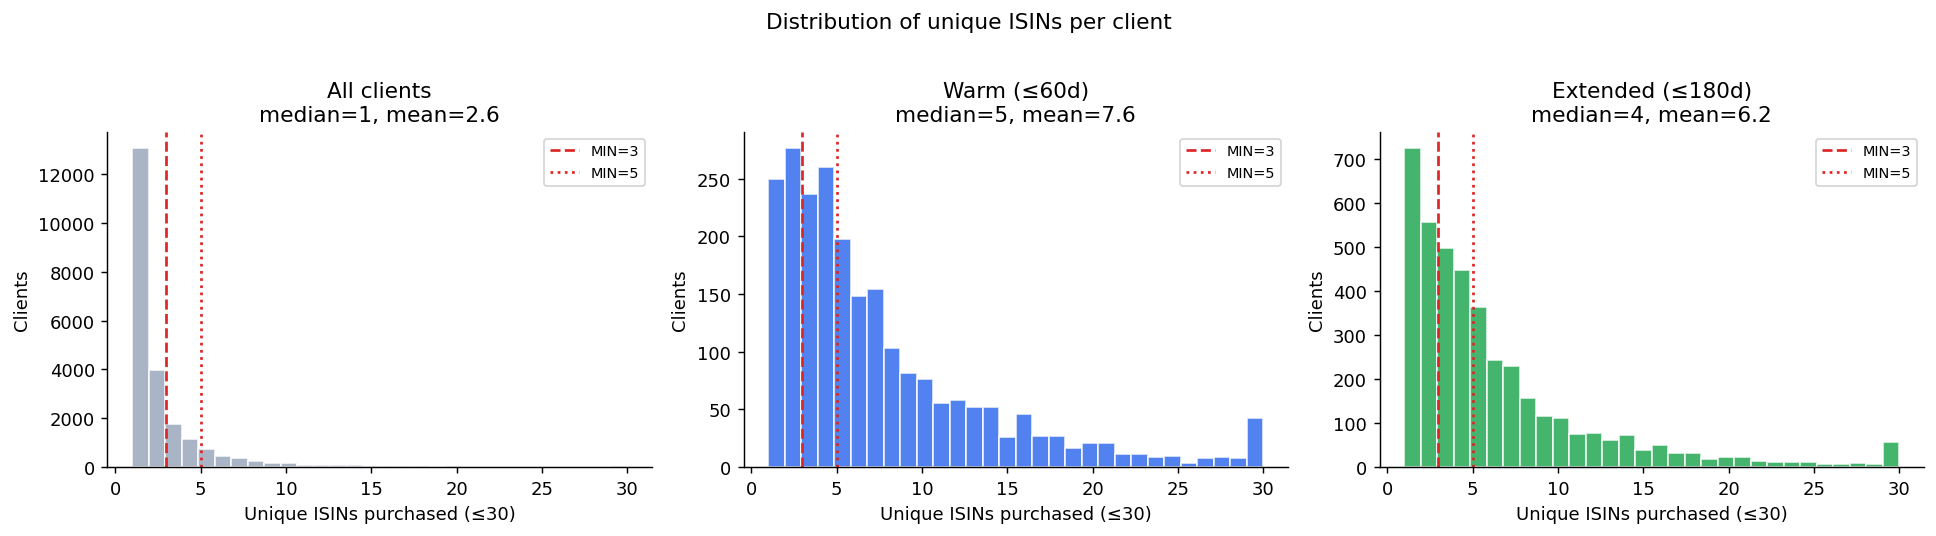


  ALS-eligible клиентов при разных MIN_TX_REC (по n_unique_isin):
     Threshold |      All |     Warm |   Extended
  ----------------------------------------------
  ≥  2 уник. ISIN |  9,816 (43%) | 2,051 (89%) |   3,361 (82%)
  ≥  3 уник. ISIN |  5,852 (26%) | 1,774 (77%) |   2,804 (69%)
  ≥  5 уник. ISIN |  2,928 (13%) | 1,277 (55%) |   1,859 (45%)
  ≥ 10 уник. ISIN |    932 (4%) |   592 (26%) |     750 (18%)


In [6]:
# 4.2 Визуализация: CDF числа уникальных ISIN на клиента
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    ("All clients", all_clients, GREY),
    ("Warm (≤60d)", hot_proxy_warm, BLUE),
    ("Extended (≤180d)", hot_proxy_extended, GREEN),
]

# Гистограммы n_unique_isin (обрезаем до 30 для читаемости)
for ax, (label, df, color) in zip(axes, datasets):
    vals = df['n_unique_isin'].clip(upper=30)
    ax.hist(vals, bins=30, color=color, alpha=0.8, edgecolor='white')
    
    # Пороги cold-start
    for thr, ls in [(3, '--'), (5, ':')]:
        ax.axvline(thr, color=RED, linestyle=ls, linewidth=1.5, label=f"MIN={thr}")
    
    ax.set_title(f"{label}\nmedian={df['n_unique_isin'].median():.0f}, mean={df['n_unique_isin'].mean():.1f}")
    ax.set_xlabel("Unique ISINs purchased (≤30)")
    ax.set_ylabel("Clients")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of unique ISINs per client", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(EDA_DIR / "cold_start_distribution.png", bbox_inches="tight")
plt.show()

# 4.3 ALS viable population при разных порогах
print("\n  ALS-eligible клиентов при разных MIN_TX_REC (по n_unique_isin):")
print(f"  {'Threshold':>12} | {'All':>8} | {'Warm':>8} | {'Extended':>10}")
print("  " + "-" * 46)
for thr in [2, 3, 5, 10]:
    a = (all_clients['n_unique_isin'] >= thr).sum()
    w = (hot_proxy_warm['n_unique_isin'] >= thr).sum()
    e = (hot_proxy_extended['n_unique_isin'] >= thr).sum()
    print(f"  ≥ {thr:>2} уник. ISIN | {a:>6,} ({a/len(all_clients):.0%}) | {w:>5,} ({w/max(len(hot_proxy_warm),1):.0%}) | {e:>7,} ({e/max(len(hot_proxy_extended),1):.0%})")


## 5. Tail concentration активов — Lorenz curve

**Gini coefficient** и **Lorenz curve** — стандартный инструмент для анализа tail concentration в recommender systems (Vargas & Castells, 2011 — popularity bias).


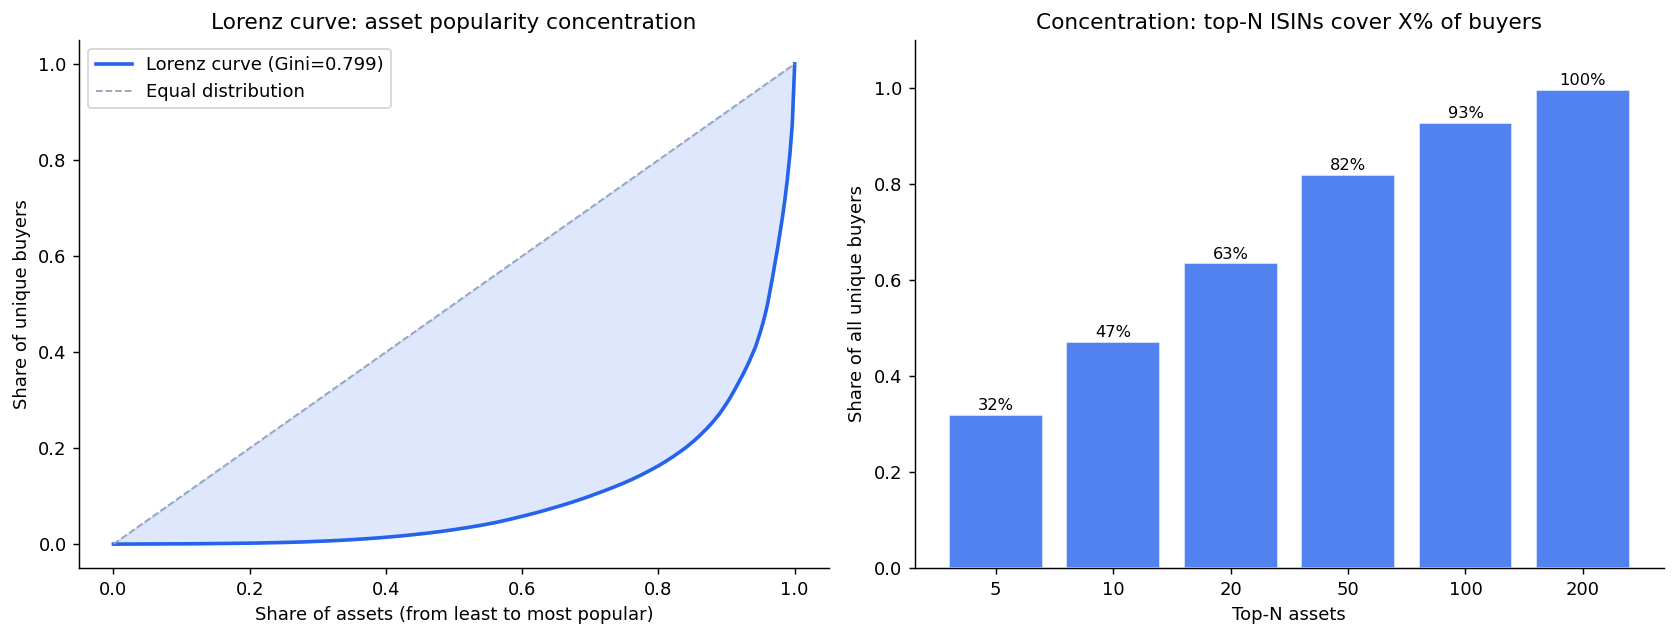

Gini coefficient (popularity): 0.7995
(0 = равномерно, 1 = монополия одного актива)

Top-10 ISIN (по уник. покупателям):
        ISIN assetCategory  n_buyers  n_transactions
GRS003003035         Stock      7501           17451
GRS015003007         Stock      3706           10613
GRS260333000         Stock      2929            3922
GRF000037009           MTF      2480            2598
GRS323003012         Stock      2166            7193
GRS014003032         Stock      1909            6902
GRS434003000         Stock      1898            4696
GRS298343005         Stock      1754            2861
GRF000038007           MTF      1692            1753
GRS393503008         Stock      1652            3800


In [7]:
# 5.1 Popularity per ISIN (число уникальных покупателей — не транзакций,
#     чтобы исключить bias от клиентов с многократными покупками одного актива)
isin_stats = tx_train.groupby('ISIN').agg(
    n_buyers=('customerID', 'nunique'),
    n_transactions=('customerID', 'count'),
    total_value=('totalValue', 'sum'),
).reset_index().merge(assets[['ISIN', 'assetCategory']], on='ISIN', how='left')

isin_stats = isin_stats.sort_values('n_buyers', ascending=False)

# 5.2 Lorenz curve
sorted_buyers = np.sort(isin_stats['n_buyers'].values)
cumshare_items = np.linspace(0, 1, len(sorted_buyers) + 1)
cumshare_buyers = np.concatenate([[0], np.cumsum(sorted_buyers) / sorted_buyers.sum()])

# Gini coefficient
gini = 1 - 2 * np.trapezoid(cumshare_buyers, cumshare_items)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(cumshare_items, cumshare_buyers, color=BLUE, linewidth=2, label=f'Lorenz curve (Gini={gini:.3f})')
ax.plot([0, 1], [0, 1], color=GREY, linestyle='--', linewidth=1, label='Equal distribution')
ax.fill_between(cumshare_items, cumshare_buyers, cumshare_items, alpha=0.15, color=BLUE)
ax.set_xlabel("Share of assets (from least to most popular)")
ax.set_ylabel("Share of unique buyers")
ax.set_title("Lorenz curve: asset popularity concentration")
ax.legend()

# Top-N concentration
ax2 = axes[1]
top_ns = [5, 10, 20, 50, 100, 200]
total_buyers_sum = isin_stats['n_buyers'].sum()
concentrations = [isin_stats.head(n)['n_buyers'].sum() / total_buyers_sum for n in top_ns]
bars = ax2.bar([str(n) for n in top_ns], concentrations, color=BLUE, alpha=0.8, edgecolor='white')
for bar, c in zip(bars, concentrations):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{c:.0%}', ha='center', fontsize=9)
ax2.set_xlabel("Top-N assets")
ax2.set_ylabel("Share of all unique buyers")
ax2.set_title("Concentration: top-N ISINs cover X% of buyers")
ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(EDA_DIR / "tail_concentration.png", bbox_inches="tight")
plt.show()

print(f"Gini coefficient (popularity): {gini:.4f}")
print(f"(0 = равномерно, 1 = монополия одного актива)")
print(f"\nTop-10 ISIN (по уник. покупателям):")
print(isin_stats.head(10)[['ISIN', 'assetCategory', 'n_buyers', 'n_transactions']].to_string(index=False))

## 6. Минимальный порог поддержки для ISIN

В литературе по CF: порог 5-10 уникальных взаимодействий считается минимумом для надёжного latent factor  
(Koren et al., 2009; Collaborative Filtering for Implicit Datasets).

In [8]:
# 6.1 Распределение числа уникальных покупателей по ISIN
print("Распределение n_buyers per ISIN:")
print(isin_stats['n_buyers'].describe(percentiles=[.1,.25,.5,.75,.9,.95]))

print("\nISIN по порогам поддержки:")
print(f"  {'Min support':>12} | {'Excluded ISINs':>15} | {'Remaining':>10} | {'Coverage':>10}")
print("  " + "-" * 55)

total_isin = len(isin_stats)
for thr in [1, 5, 10, 20, 50]:
    remaining = (isin_stats['n_buyers'] >= thr).sum()
    excluded = total_isin - remaining
    # Какой % транзакций остаётся
    tx_remaining = isin_stats[isin_stats['n_buyers'] >= thr]['n_transactions'].sum()
    cov = tx_remaining / isin_stats['n_transactions'].sum()
    print(f"  ≥ {thr:>3} buyers   | {excluded:>8,} ({excluded/total_isin:.0%}) | {remaining:>7,} ({remaining/total_isin:.0%}) | {cov:>9.1%} tx")

# 6.2 По категориям
print("\nISIN по категориям и порогу ≥5 покупателей:")
cat_thr = isin_stats.groupby('assetCategory').apply(
    lambda g: pd.Series({
        'total_isin': len(g),
        'isin_ge5': (g['n_buyers'] >= 5).sum(),
        'isin_ge10': (g['n_buyers'] >= 10).sum(),
    })
).reset_index()
print(cat_thr.to_string(index=False))

Распределение n_buyers per ISIN:
count     279.000000
mean      211.010753
std       625.147629
min         1.000000
10%         2.000000
25%         7.000000
50%        44.000000
75%       128.000000
90%       449.200000
95%       952.200000
max      7501.000000
Name: n_buyers, dtype: float64

ISIN по порогам поддержки:
   Min support |  Excluded ISINs |  Remaining |   Coverage
  -------------------------------------------------------
  ≥   1 buyers   |        0 (0%) |     279 (100%) |    100.0% tx
  ≥   5 buyers   |       56 (20%) |     223 (80%) |     99.8% tx
  ≥  10 buyers   |       76 (27%) |     203 (73%) |     99.5% tx
  ≥  20 buyers   |      103 (37%) |     176 (63%) |     98.8% tx
  ≥  50 buyers   |      149 (53%) |     130 (47%) |     96.1% tx

ISIN по категориям и порогу ≥5 покупателей:
assetCategory  total_isin  isin_ge5  isin_ge10
         Bond          34        17         16
          MTF          43        27         23
        Stock         202       179        164


## 7. Временное окно взаимодействий — temporal decay анализ

Анализируем, насколько сигнал из разных временных окон предсказывает будущие покупки.  
**Proxy-метрика:** correlation между покупками в окне [T-W, T) и покупками в [T, T+30d).



In [9]:
# 7.1 Анализ: покупали ли те же ISIN в разных временных окнах до и после T?
# T = TRAIN_END (2021-01-01)
# Будущие покупки [T, T+90d]
FUTURE_WINDOW = 90

future_tx = tx[(tx['timestamp'] >= TRAIN_END) & 
               (tx['timestamp'] < TRAIN_END + pd.Timedelta(days=FUTURE_WINDOW))]

future_pairs = set(zip(future_tx['customerID'], future_tx['ISIN']))

# Для каждого клиента с будущей покупкой: совпали ли ISIN из разных исторических окон?
print("  Repeat-buy rate: доля будущих покупок, которые уже были в истории")
print(f"  {'Window':>8} | {'Repeat rate':>12} | {'Unique matches':>15}")
print("  " + "-" * 42)

for window in [90, 180, 365, 548, 730, None]:
    label = f"{window}d" if window else "all"
    if window:
        cutoff = TRAIN_END - pd.Timedelta(days=window)
        hist = tx[(tx['timestamp'] >= cutoff) & (tx['timestamp'] < TRAIN_END)]
    else:
        hist = tx_train
    hist_pairs = set(zip(hist['customerID'], hist['ISIN']))
    matches = len(future_pairs & hist_pairs)
    rate = matches / max(len(future_pairs), 1)
    print(f"  {label:>8} | {rate:>11.1%} | {matches:>15,}")

  Repeat-buy rate: доля будущих покупок, которые уже были в истории
    Window |  Repeat rate |  Unique matches
  ------------------------------------------
       90d |       27.8% |           2,561
      180d |       33.3% |           3,065
      365d |       42.1% |           3,870
      548d |       42.5% |           3,911
      730d |       42.9% |           3,950
       all |       47.5% |           4,375


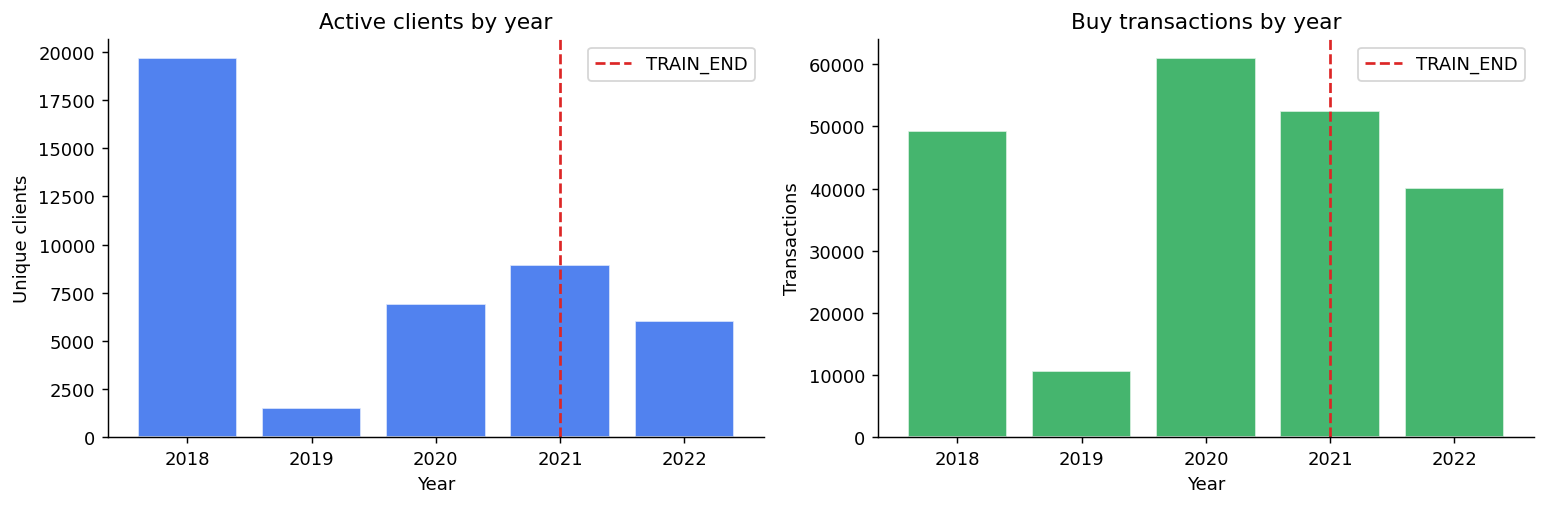

 year  n_clients  n_isin  n_tx
 2018      19704     241 49329
 2019       1507     198 10609
 2020       6915     199 61045
 2021       8930     206 52486
 2022       6028     201 40170


In [10]:
# 7.2 Активность клиентов по годам — сколько уникальных клиентов покупают в каждый год?
tx['year'] = tx['timestamp'].dt.year

yearly = tx.groupby('year').agg(
    n_clients=('customerID', 'nunique'),
    n_isin=('ISIN', 'nunique'),
    n_tx=('customerID', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(yearly['year'], yearly['n_clients'], color=BLUE, alpha=0.8, edgecolor='white')
ax.set_title("Active clients by year")
ax.set_xlabel("Year")
ax.set_ylabel("Unique clients")
ax.axvline(2021, color=RED, linestyle='--', linewidth=1.5, label='TRAIN_END')
ax.legend()

ax2 = axes[1]
ax2.bar(yearly['year'], yearly['n_tx'], color=GREEN, alpha=0.8, edgecolor='white')
ax2.set_title("Buy transactions by year")
ax2.set_xlabel("Year")
ax2.set_ylabel("Transactions")
ax2.axvline(2021, color=RED, linestyle='--', linewidth=1.5, label='TRAIN_END')
ax2.legend()

plt.tight_layout()
plt.savefig(EDA_DIR / "temporal_activity.png", bbox_inches="tight")
plt.show()
print(yearly.to_string(index=False))

## 8. Repeat purchase анализ — фильтр уже купленных

Анализируем: как часто клиенты покупают один и тот же ISIN повторно? Какой период — разумный порог фильтра?

In [11]:
# 8.1 Repeat buy: одна и та же пара (customerID, ISIN) встречается сколько раз?
pair_counts = tx_train.groupby(['customerID', 'ISIN']).size().reset_index(name='n_buys')

print("Распределение числа покупок одной пары (клиент, ISIN):")
vc = pair_counts['n_buys'].value_counts().sort_index()
total_pairs = len(pair_counts)
print(f"  {'n_buys':>8} | {'Pairs':>10} | {'%':>6}")
for n, cnt in vc.head(10).items():
    print(f"  {n:>8} | {cnt:>10,} | {cnt/total_pairs:>5.1%}")
repeat_rate = (pair_counts['n_buys'] > 1).mean()
print(f"\nДоля пар с repeat-buy (>1 покупки): {repeat_rate:.1%}")
print(f"Доля пар с 1 покупкой:              {1-repeat_rate:.1%}")

Распределение числа покупок одной пары (клиент, ISIN):
    n_buys |      Pairs |      %
         1 |     43,459 | 73.8%
         2 |      6,125 | 10.4%
         3 |      2,936 |  5.0%
         4 |      1,678 |  2.9%
         5 |      1,137 |  1.9%
         6 |        789 |  1.3%
         7 |        558 |  0.9%
         8 |        345 |  0.6%
         9 |        290 |  0.5%
        10 |        239 |  0.4%

Доля пар с repeat-buy (>1 покупки): 26.2%
Доля пар с 1 покупкой:              73.8%


Интервалы между повторными покупками одного ISIN (дней):
count    62111.000000
mean       104.936179
std        219.782234
min          0.000000
10%          1.000000
25%          4.000000
50%         16.000000
75%         70.000000
90%        297.000000
95%        780.000000
max       1094.000000
Name: gap_days, dtype: float64


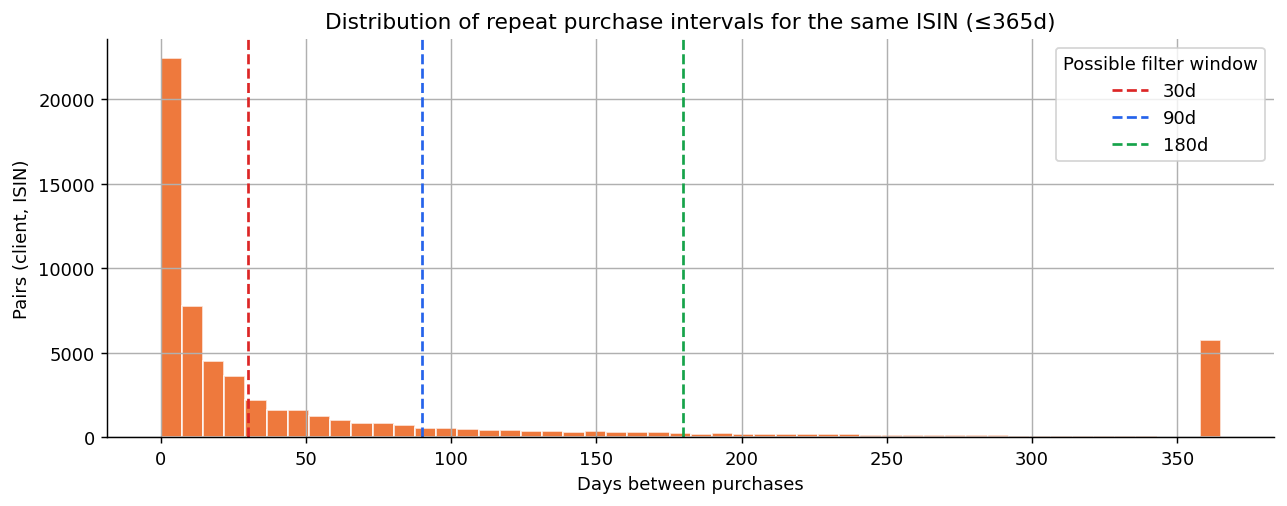


Доля repeat-buy с интервалом ≤ N дней:
  ≤   7d: 36.2%
  ≤  14d: 48.7%
  ≤  30d: 62.3%
  ≤  60d: 72.9%
  ≤  90d: 78.5%
  ≤ 180d: 85.7%


In [12]:
# 8.2 Для repeat-buy пар: медианный интервал между повторными покупками одного ISIN
tx_sorted = tx_train.sort_values(['customerID', 'ISIN', 'timestamp'])

# Вычисляем интервалы между повторными покупками одного ISIN
tx_sorted['prev_buy'] = tx_sorted.groupby(['customerID', 'ISIN'])['timestamp'].shift(1)
tx_sorted['gap_days'] = (tx_sorted['timestamp'] - tx_sorted['prev_buy']).dt.days

repeat_gaps = tx_sorted[tx_sorted['gap_days'].notna()]['gap_days']

print("Интервалы между повторными покупками одного ISIN (дней):")
print(repeat_gaps.describe(percentiles=[.1,.25,.5,.75,.9,.95]))

fig, ax = plt.subplots(figsize=(10, 4))
repeat_gaps.clip(upper=365).hist(bins=50, ax=ax, color=ORANGE, alpha=0.8, edgecolor='white')
for thr, color in [(30, RED), (90, BLUE), (180, GREEN)]:
    ax.axvline(thr, color=color, linestyle='--', linewidth=1.5, label=f'{thr}d')
ax.set_title("Distribution of repeat purchase intervals for the same ISIN (≤365d)")
ax.set_xlabel("Days between purchases")
ax.set_ylabel("Pairs (client, ISIN)")
ax.legend(title="Possible filter window")
plt.tight_layout()
plt.savefig(EDA_DIR / "repeat_buy_gaps.png", bbox_inches="tight")
plt.show()

print("\nДоля repeat-buy с интервалом ≤ N дней:")
for thr in [7, 14, 30, 60, 90, 180]:
    pct = (repeat_gaps <= thr).mean()
    print(f"  ≤ {thr:>3}d: {pct:.1%}")

## 9. Risk profile × Asset category — верификация маппинга

Смотрим реальное распределение категорий активов по риск-профилям клиентов.



In [13]:
# 9.1 Профиль клиентов на дату TRAIN_END
profile_at_train = get_customer_profile_at(customers, TRAIN_END)

# Клиенты с транзакциями в train set
active_ids = tx_train['customerID'].unique()
profile_active = profile_at_train[profile_at_train['customerID'].isin(active_ids)]

print(f"Профили активных клиентов (с транзакциями до {TRAIN_END.date()}):")
print(f"  Всего: {len(profile_active):,}")
print(f"  С предсказанным профилем: {profile_active['is_profile_predicted'].sum():,} ({profile_active['is_profile_predicted'].mean():.1%})")
print("\n  Распределение riskLevel:")
print(profile_active['riskLevel'].value_counts().to_string())

Профили активных клиентов (с транзакциями до 2021-01-01):
  Всего: 20,969
  С предсказанным профилем: 5,800 (27.7%)

  Распределение riskLevel:
riskLevel
Income           8313
Balanced         5767
Conservative     4799
Aggressive       1803
Not_Available     287



  Реальный % покупок по категориям (по riskLevel):
assetCategory  Bond   MTF  Stock
riskLevel                       
Aggressive      2.3   3.4   94.3
Balanced        1.2   3.9   94.9
Conservative    0.5  23.3   76.2
Income          0.9   8.1   91.0


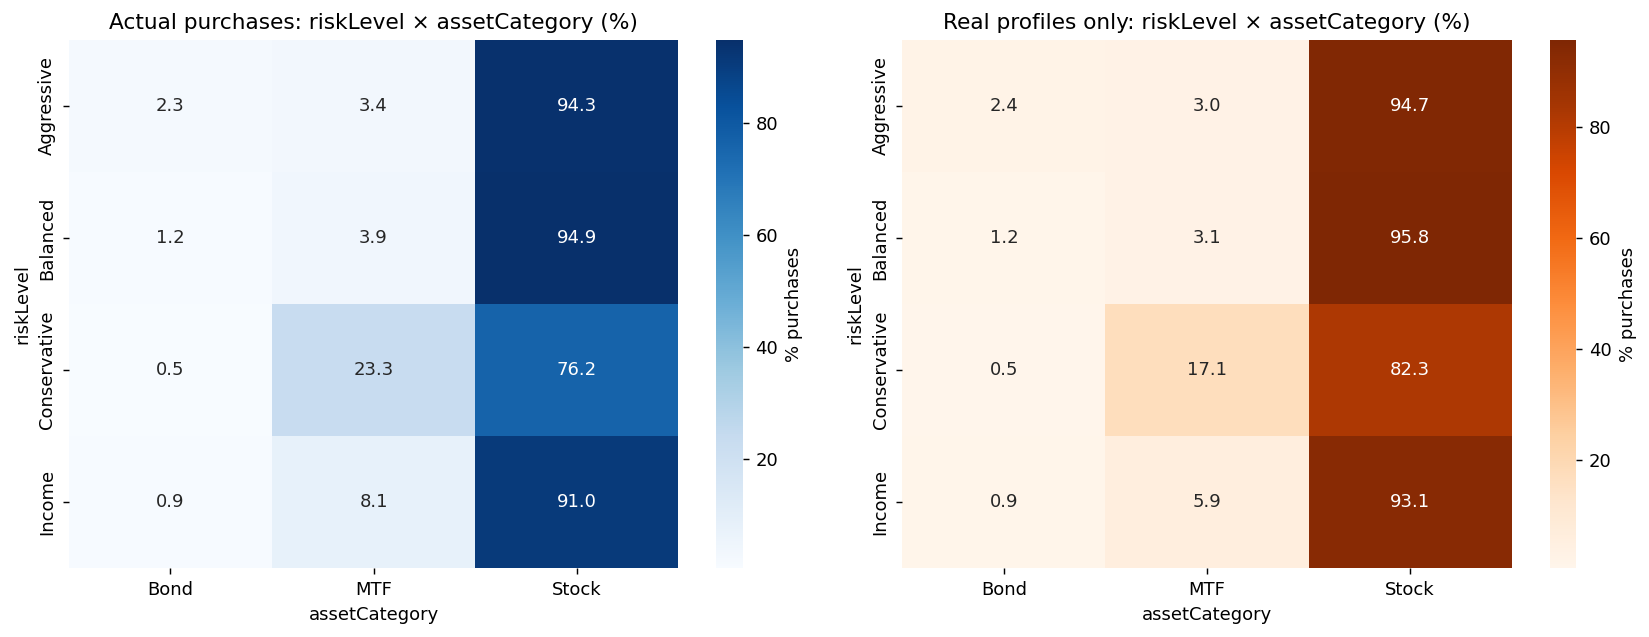


  Только реальные профили — 106,916 транзакций:
assetCategory  Bond   MTF  Stock
riskLevel                       
Aggressive      2.4   3.0   94.7
Balanced        1.2   3.1   95.8
Conservative    0.5  17.1   82.3
Income          0.9   5.9   93.1


In [14]:
# 9.2 Кросс-таблица: riskLevel × assetCategory (реальные покупки)
tx_with_profile = tx_train.merge(
    profile_active[['customerID', 'riskLevel', 'is_profile_predicted']],
    on='customerID', how='left'
).merge(assets[['ISIN', 'assetCategory']], on='ISIN', how='left')

# Только клиенты с известным профилем
tx_known = tx_with_profile[tx_with_profile['riskLevel'] != 'Not_Available']

cross = tx_known.groupby(['riskLevel', 'assetCategory']).size().unstack(fill_value=0)
# Нормируем по строкам (% от покупок каждого риск-уровня)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

print("\n  Реальный % покупок по категориям (по riskLevel):")
print(cross_pct.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap с реальными числами
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': '% purchases'})
axes[0].set_title("Actual purchases: riskLevel × assetCategory (%)")
axes[0].set_ylabel("riskLevel")

# Только реальные (не предсказанные) профили
tx_real_profile = tx_known[tx_known['is_profile_predicted'] == 0]
cross_real = tx_real_profile.groupby(['riskLevel', 'assetCategory']).size().unstack(fill_value=0)
cross_real_pct = cross_real.div(cross_real.sum(axis=1), axis=0) * 100
sns.heatmap(cross_real_pct, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1],
            cbar_kws={'label': '% purchases'})
axes[1].set_title("Real profiles only: riskLevel × assetCategory (%)")
axes[1].set_ylabel("riskLevel")

plt.tight_layout()
plt.savefig(EDA_DIR / "risk_vs_category.png", bbox_inches="tight")
plt.show()

print(f"\n  Только реальные профили — {len(tx_real_profile):,} транзакций:")
print(cross_real_pct.round(1).to_string())

In [15]:
# 9.3 Предсказанные vs реальные профили: есть ли систематическая разница в поведении?
cross_pred = tx_with_profile[tx_with_profile['is_profile_predicted'] == 1].groupby(
    ['riskLevel', 'assetCategory']).size().unstack(fill_value=0)
cross_pred_pct = cross_pred.div(cross_pred.sum(axis=1), axis=0) * 100

print("  Предсказанные профили — распределение покупок по категориям (%):")
print(cross_pred_pct.round(1).to_string())

# Число клиентов с предсказанным профилем среди активных
n_pred = profile_active[profile_active['is_profile_predicted'] == 1]
print(f"\n  Клиентов с предсказанным профилем: {len(n_pred):,} ({len(n_pred)/len(profile_active):.1%})")
print("  riskLevel предсказанных клиентов:")
print(n_pred['riskLevel'].value_counts().to_string())

  Предсказанные профили — распределение покупок по категориям (%):
assetCategory  Bond   MTF  Stock
riskLevel                       
Aggressive      1.2  19.6   79.2
Balanced        1.2  23.8   75.0
Conservative    0.5  31.1   68.3
Income          0.7  24.4   75.0

  Клиентов с предсказанным профилем: 5,800 (27.7%)
  riskLevel предсказанных клиентов:
riskLevel
Conservative    2384
Income          2131
Balanced        1074
Aggressive       211


## 10. Портфельная структура клиентов

Анализируем реальную структуру портфелей: stock-only vs mixed.



In [16]:
# 10.1 Для каждого клиента: категории активов в портфеле
portfolio = tx_train.merge(assets[['ISIN', 'assetCategory']], on='ISIN', how='left')
client_categories = portfolio.groupby('customerID')['assetCategory'].apply(set).reset_index()
client_categories.columns = ['customerID', 'categories']

client_categories['has_stock'] = client_categories['categories'].apply(lambda s: 'Stock' in s)
client_categories['has_bond']  = client_categories['categories'].apply(lambda s: 'Bond' in s)
client_categories['has_mtf']   = client_categories['categories'].apply(lambda s: 'MTF' in s)
client_categories['n_cat']     = client_categories['categories'].apply(len)

print("Портфельная структура клиентов (training set):")
print(f"  Всего клиентов с покупками: {len(client_categories):,}")
print(f"  Только Stock:              {(client_categories['has_stock'] & ~client_categories['has_bond'] & ~client_categories['has_mtf']).sum():,} ({(client_categories['has_stock'] & ~client_categories['has_bond'] & ~client_categories['has_mtf']).mean():.1%})")
print(f"  Только Bond:               {(~client_categories['has_stock'] & client_categories['has_bond'] & ~client_categories['has_mtf']).sum():,} ({(~client_categories['has_stock'] & client_categories['has_bond'] & ~client_categories['has_mtf']).mean():.1%})")
print(f"  Только MTF:                {(~client_categories['has_stock'] & ~client_categories['has_bond'] & client_categories['has_mtf']).sum():,} ({(~client_categories['has_stock'] & ~client_categories['has_bond'] & client_categories['has_mtf']).mean():.1%})")
print(f"  Stock + Bond:              {(client_categories['has_stock'] & client_categories['has_bond'] & ~client_categories['has_mtf']).sum():,}")
print(f"  Stock + MTF:               {(client_categories['has_stock'] & ~client_categories['has_bond'] & client_categories['has_mtf']).sum():,}")
print(f"  Bond + MTF:                {(~client_categories['has_stock'] & client_categories['has_bond'] & client_categories['has_mtf']).sum():,}")
print(f"  Все три категории:         {(client_categories['has_stock'] & client_categories['has_bond'] & client_categories['has_mtf']).sum():,}")
print(f"\n  1 категория:               {(client_categories['n_cat'] == 1).sum():,} ({(client_categories['n_cat'] == 1).mean():.1%})")
print(f"  2 категории:               {(client_categories['n_cat'] == 2).sum():,}")
print(f"  3 категории:               {(client_categories['n_cat'] == 3).sum():,}")

Портфельная структура клиентов (training set):
  Всего клиентов с покупками: 22,905
  Только Stock:              15,963 (69.7%)
  Только Bond:               458 (2.0%)
  Только MTF:                5,487 (24.0%)
  Stock + Bond:              279
  Stock + MTF:               622
  Bond + MTF:                43
  Все три категории:         53

  1 категория:               21,908 (95.6%)
  2 категории:               944
  3 категории:               53


Портфельная структура по riskLevel:
    riskLevel  n_clients  stock_only  pct_diversified  mean_categories
   Aggressive       1803        1236         0.099834         1.110926
     Balanced       5767        4124         0.059997         1.063985
 Conservative       4799        2889         0.033549         1.034174
       Income       8313        5674         0.036208         1.037050
Not_Available        287         104         0.031359         1.031359


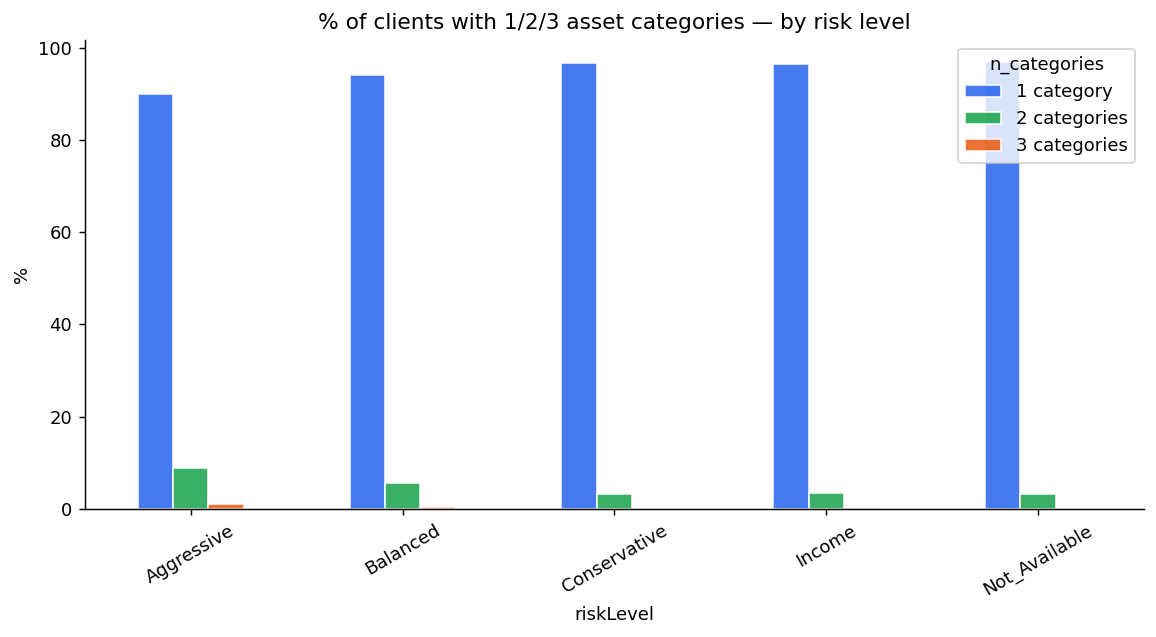

In [17]:
# 10.2 Портфельная структура по рискам — подтверждаем паттерн
portfolio_with_risk = client_categories.merge(
    profile_active[['customerID', 'riskLevel']], on='customerID', how='left'
)

portfolio_risk_stats = portfolio_with_risk.groupby('riskLevel').agg(
    n_clients=('customerID', 'count'),
    stock_only=('has_stock', lambda x: (x & ~portfolio_with_risk.loc[x.index, 'has_bond'] & ~portfolio_with_risk.loc[x.index, 'has_mtf']).sum()),
    pct_diversified=('n_cat', lambda x: (x > 1).mean()),
    mean_categories=('n_cat', 'mean'),
).reset_index()

print("Портфельная структура по riskLevel:")
print(portfolio_risk_stats.to_string(index=False))

# 10.3 Кросс: riskLevel × n_categories
cross_portfolio = portfolio_with_risk.groupby(['riskLevel', 'n_cat']).size().unstack(fill_value=0)
cross_portfolio_pct = cross_portfolio.div(cross_portfolio.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
cross_portfolio_pct.plot(kind='bar', ax=ax, color=[BLUE, GREEN, ORANGE], edgecolor='white', alpha=0.85)
ax.set_title("% of clients with 1/2/3 asset categories — by risk level")
ax.set_xlabel("riskLevel")
ax.set_ylabel("%")
ax.legend(title="n_categories", labels=['1 category', '2 categories', '3 categories'])
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(EDA_DIR / "portfolio_diversity_by_risk.png", bbox_inches="tight")
plt.show()


## 11. Co-purchase patterns — межкатегорийные покупки

Анализируем: как часто клиент, купивший Stock, затем покупает Bond или MTF?  
Это основа для понимания, насколько диверсификационный буст вообще применим.

Также — item-item co-occurrence: какие активы покупаются совместно?  
Это напрямую валидирует item-based CF подход.



In [18]:
# 11.1 Category-level co-purchase: P(купил cat B | купил cat A)
cat_pairs = []
for cid, group in portfolio.groupby('customerID'):
    cats = list(group['assetCategory'].dropna().unique())
    for ca in cats:
        for cb in cats:
            cat_pairs.append({'from': ca, 'to': cb})

cat_pair_df = pd.DataFrame(cat_pairs)
co_matrix = cat_pair_df[cat_pair_df['from'] != cat_pair_df['to']].groupby(
    ['from', 'to']).size().unstack(fill_value=0)

# Нормируем на число клиентов купивших 'from'
from_counts = cat_pair_df.groupby('from').apply(lambda g: g['to'].eq(g['from']).sum() + 0).add(
    portfolio.groupby('customerID')['assetCategory'].apply(lambda x: len(set(x)))).groupby(
    portfolio.merge(pd.DataFrame(cat_pairs), left_on='customerID', right_on='from')['assetCategory']).size()

# Проще: просто смотрим % клиентов купивших cat B среди тех, кто купил cat A
cats = ['Stock', 'Bond', 'MTF']
buyers_per_cat = {}
for cat in cats:
    buyers_per_cat[cat] = set(portfolio[portfolio['assetCategory'] == cat]['customerID'])

print("Conditional purchase rate: P(купил cat B | купил cat A) — % клиентов")
print(f"  {'From → To':>20} | {'Bond':>8} | {'MTF':>8} | {'Stock':>8}")
print("  " + "-" * 52)
for cat_a in cats:
    row = f"  {cat_a:>20} |"
    for cat_b in ['Bond', 'MTF', 'Stock']:
        if cat_a == cat_b:
            row += f"  {'—':>7}|"
        else:
            both = len(buyers_per_cat[cat_a] & buyers_per_cat[cat_b])
            pct = both / max(len(buyers_per_cat[cat_a]), 1)
            row += f" {pct:>7.1%} |"
    print(row)

Conditional purchase rate: P(купил cat B | купил cat A) — % клиентов
             From → To |     Bond |      MTF |    Stock
  ----------------------------------------------------
                 Stock |    2.0% |    4.0% |        —|
                  Bond |        —|   11.5% |   39.9% |
                   MTF |    1.5% |        —|   10.9% |


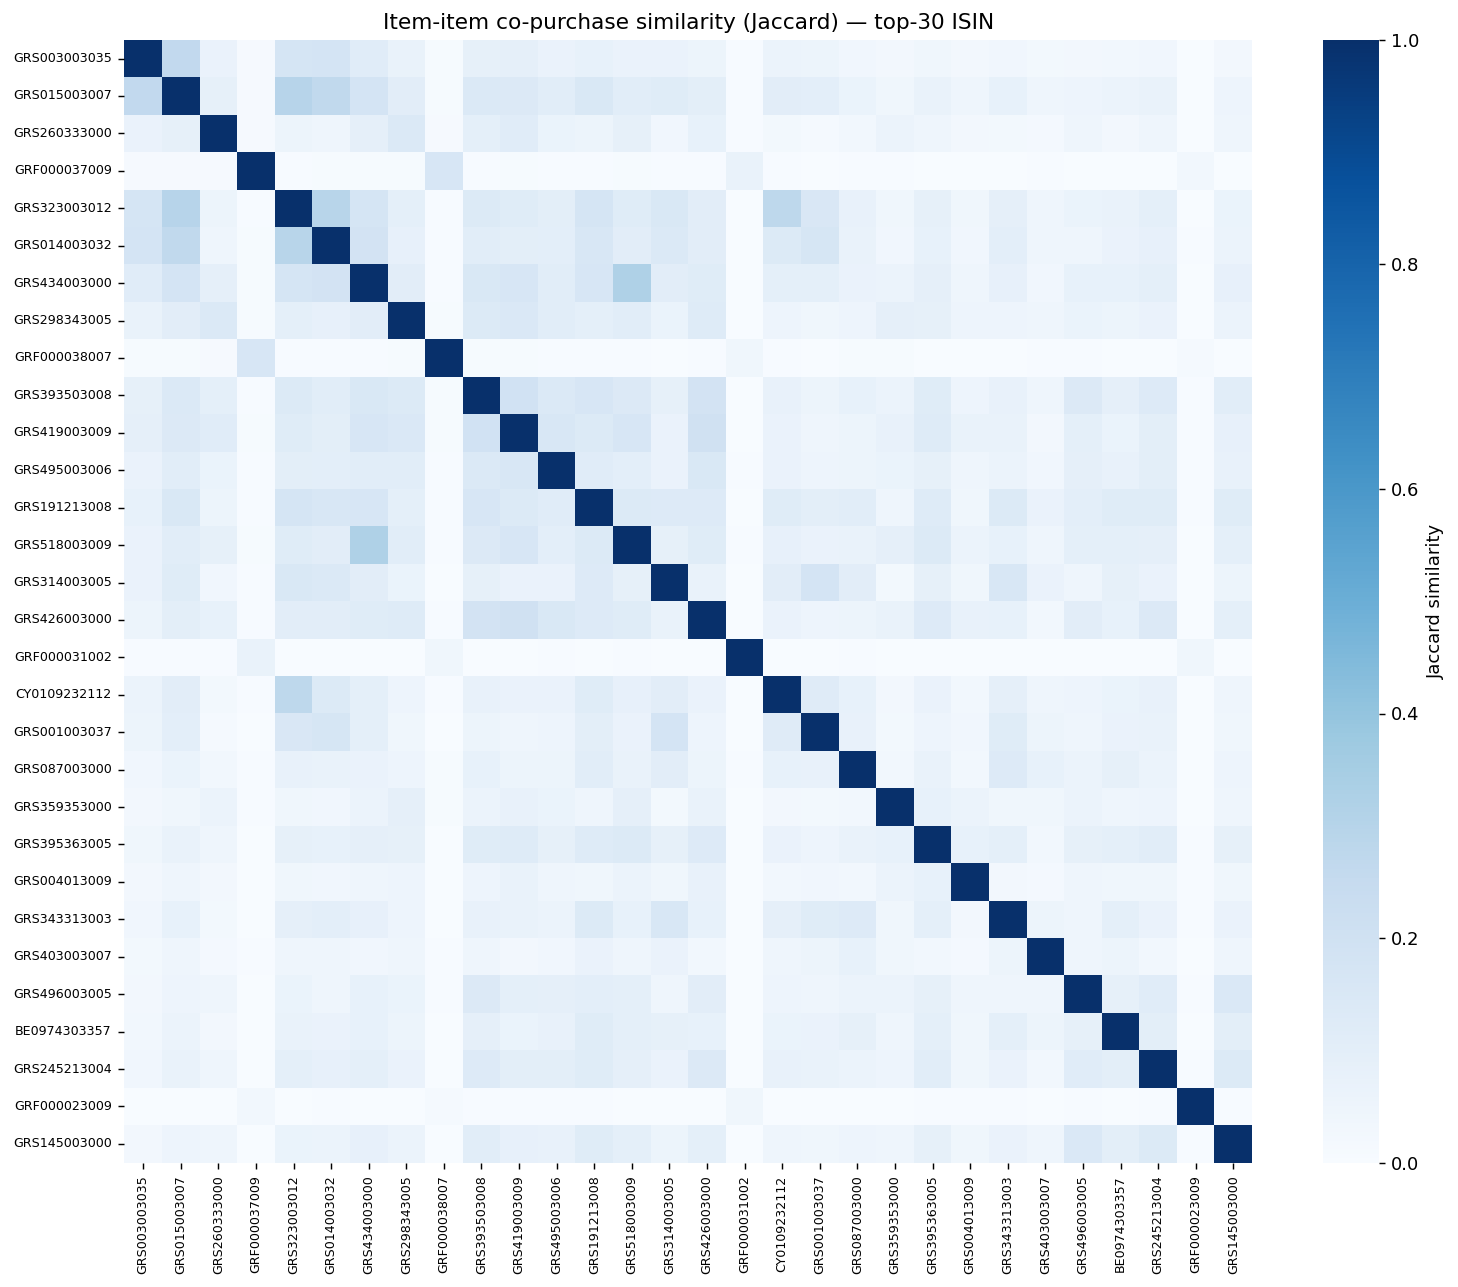


Среднее Jaccard similarity:
  Внутри одной категории: 0.0863
  Между категориями:      0.0050
  (выше внутри → item-based CF имеет смысл по категориям)


In [19]:
# 11.2 Item-item co-purchase heatmap (top-30 ISIN по популярности)
top_isin = isin_stats.head(30)['ISIN'].tolist()
tx_top = tx_train[tx_train['ISIN'].isin(top_isin)]

# Для каждой пары ISIN: число клиентов, купивших оба
client_isin_sets = tx_top.groupby('customerID')['ISIN'].apply(set).reset_index()

cooccur = pd.DataFrame(0, index=top_isin, columns=top_isin)
for _, row in client_isin_sets.iterrows():
    isins = list(row['ISIN'])
    for i in isins:
        for j in isins:
            if i in cooccur.index and j in cooccur.columns:
                cooccur.loc[i, j] += 1

# Нормируем (Jaccard-style: |A∩B| / |A∪B|)
diag = np.diag(cooccur.values)
union = diag[:, None] + diag[None, :] - cooccur.values
jaccard = cooccur.values / np.maximum(union, 1)
jaccard_df = pd.DataFrame(jaccard, index=top_isin, columns=top_isin)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(jaccard_df, ax=ax, cmap='Blues', xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Jaccard similarity'})
ax.set_title("Item-item co-purchase similarity (Jaccard) — top-30 ISIN")
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.savefig(EDA_DIR / "item_cooccurrence.png", bbox_inches="tight")
plt.show()

# Среднее Jaccard для пар внутри и между категориями
isin_cat = assets.set_index('ISIN')['assetCategory'].to_dict()
within_scores, cross_scores = [], []
isin_list = jaccard_df.index.tolist()
for i, a in enumerate(isin_list):
    for j, b in enumerate(isin_list):
        if i >= j: continue
        val = jaccard_df.iloc[i, j]
        if isin_cat.get(a) == isin_cat.get(b):
            within_scores.append(val)
        else:
            cross_scores.append(val)
print(f"\nСреднее Jaccard similarity:")
print(f"  Внутри одной категории: {np.mean(within_scores):.4f}")
print(f"  Между категориями:      {np.mean(cross_scores):.4f}")
print(f"  (выше внутри → item-based CF имеет смысл по категориям)")

## 12. Feasibility оценки: Leave-One-Out validation

Считаем: сколько клиентов пройдут LOO-фильтр, и какая это доля от hot_customers.



In [20]:
# 12.1 LOO feasibility
print("LOO-eligible клиентов при разных MIN_TX_EVAL (n_unique_isin ≥ thr):")
print("(нужно ≥ thr уникальных ISIN: после изъятия одного остаётся ≥ thr-1 для построения матрицы)")
print()
print(f"  {'MIN_TX_EVAL':>12} | {'All clients':>13} | {'Warm proxy':>12} | {'Extended':>10}")
print("  " + "-" * 55)

for thr in [2, 3, 5, 10]:
    a = (customer_stats['n_unique_isin'] >= thr).sum()
    w = (hot_proxy_warm['n_unique_isin'] >= thr).sum()
    e = (hot_proxy_extended['n_unique_isin'] >= thr).sum()
    print(f"  ≥ {thr:>2} уник. ISIN | {a:>7,} ({a/len(customer_stats):.0%}) | {w:>6,} ({w/max(len(hot_proxy_warm),1):.0%}) | {e:>6,} ({e/max(len(hot_proxy_extended),1):.0%})")

# 12.2 Разные сплиты для оценки
# Validation: клиенты купившие что-то в [TRAIN_END, VALID_END)
val_buyers = set(tx[(tx['timestamp'] >= TRAIN_END) & (tx['timestamp'] < VALID_END)]['customerID'])
# Из них — с достаточной историей
eligible_val = customer_stats[
    (customer_stats['customerID'].isin(val_buyers)) &
    (customer_stats['n_unique_isin'] >= 3)
]

print(f"\n  Клиентов с покупкой в validation период: {len(val_buyers):,}")
print(f"  Из них с ≥3 уник. ISIN в истории:       {len(eligible_val):,} ({len(eligible_val)/max(len(val_buyers),1):.1%})")
print(f"  → Это реальный validation set для LOO оценки ALS")

LOO-eligible клиентов при разных MIN_TX_EVAL (n_unique_isin ≥ thr):
(нужно ≥ thr уникальных ISIN: после изъятия одного остаётся ≥ thr-1 для построения матрицы)

   MIN_TX_EVAL |   All clients |   Warm proxy |   Extended
  -------------------------------------------------------
  ≥  2 уник. ISIN |   9,816 (43%) |  2,051 (89%) |  3,361 (82%)
  ≥  3 уник. ISIN |   5,852 (26%) |  1,774 (77%) |  2,804 (69%)
  ≥  5 уник. ISIN |   2,928 (13%) |  1,277 (55%) |  1,859 (45%)
  ≥ 10 уник. ISIN |     932 (4%) |    592 (26%) |    750 (18%)

  Клиентов с покупкой в validation период: 7,680
  Из них с ≥3 уник. ISIN в истории:       2,816 (36.7%)
  → Это реальный validation set для LOO оценки ALS


## 13. Гиперпараметр k для ALS: что разумно при данной разреженности?

Согласно Koren et al. (2009) и практике implicit ALS:  
**k должен быть значительно меньше sqrt(min(n_users, n_items))**.

При n_users ≈ 12K и n_items ≈ 800 и плотности ~1%:  
- sqrt(800) ≈ 28 → верхняя граница k ≈ 20-25
- Рекомендуемый grid: k ∈ {8, 12, 16, 24, 32}



In [21]:
# 13.1 Вычислим реальные n_users, n_items при разных порогах поддержки
print("Параметры матрицы при разных порогах MIN_USER_TX и MIN_ITEM_SUPPORT:")
print(f"  {'MIN_U':>6} | {'MIN_I':>6} | {'Users':>7} | {'Items':>7} | {'Density':>9} | {'k_max рек.':>10}")
print("  " + "-" * 58)

tx_window = tx_train  # использовать полную историю или INTERACTION_WINDOW

for min_u in [1, 3, 5]:
    for min_i in [5, 10]:
        user_counts = tx_window.groupby('customerID')['ISIN'].nunique()
        item_counts = tx_window.groupby('ISIN')['customerID'].nunique()
        
        valid_users = user_counts[user_counts >= min_u].index
        valid_items = item_counts[item_counts >= min_i].index
        
        sub = tx_window[
            tx_window['customerID'].isin(valid_users) & 
            tx_window['ISIN'].isin(valid_items)
        ]
        
        u = sub['customerID'].nunique()
        i = sub['ISIN'].nunique()
        p = sub.groupby(['customerID', 'ISIN']).size().count()
        d = p / (u * i) if u * i > 0 else 0
        k_max = max(4, int(np.sqrt(min(u, i)) * 0.7))
        
        print(f"  ≥{min_u:>4}u | ≥{min_i:>4}i | {u:>7,} | {i:>7,} | {d:>9.3%} | k≤{k_max:>7}")

print("\n  Рекомендуемый grid search для k: {8, 12, 16, 24, 32}")
print("  (при текущей разреженности k=50 из первоначального плана — избыточно)")

Параметры матрицы при разных порогах MIN_USER_TX и MIN_ITEM_SUPPORT:
   MIN_U |  MIN_I |   Users |   Items |   Density | k_max рек.
  ----------------------------------------------------------
  ≥   1u | ≥   5i |  22,869 |     223 |    1.152% | k≤     10
  ≥   1u | ≥  10i |  22,840 |     203 |    1.264% | k≤      9
  ≥   3u | ≥   5i |   5,848 |     221 |    2.923% | k≤     10
  ≥   3u | ≥  10i |   5,848 |     203 |    3.175% | k≤      9
  ≥   5u | ≥   5i |   2,927 |     220 |    4.327% | k≤     10
  ≥   5u | ≥  10i |   2,927 |     203 |    4.678% | k≤      9

  Рекомендуемый grid search для k: {8, 12, 16, 24, 32}
  (при текущей разреженности k=50 из первоначального плана — избыточно)


## 14. Популярные активы как fallback — что предлагать?

Если большинство клиентов попадёт в popularity fallback,  
важно понять: насколько популярные активы реально покрывают разные риск-профили?




  Top-10 Stock по уник. покупателям:
        ISIN  n_buyers  n_transactions
GRS003003035      7501           17451
GRS015003007      3706           10613
GRS260333000      2929            3922
GRS323003012      2166            7193
GRS014003032      1909            6902
GRS434003000      1898            4696
GRS298343005      1754            2861
GRS393503008      1652            3800
GRS419003009      1605            3730
GRS495003006      1323            2341

  Top-10 Bond по уник. покупателям:
        ISIN  n_buyers  n_transactions
GRC419120AD7       279             281
GRC813119AD1       198             215
GRC1451184D4       160             185
GRC4951193D4       121             178
GRC8161185B1       109             123
GRC3931176B0       102             118
GRC1441197B3        57             121
GR0128016731        26              28
GR0124036709        23              24
GRC8171186B7        21              37

  Top-10 MTF по уник. покупателям:
        ISIN  n_buyers  n_trans

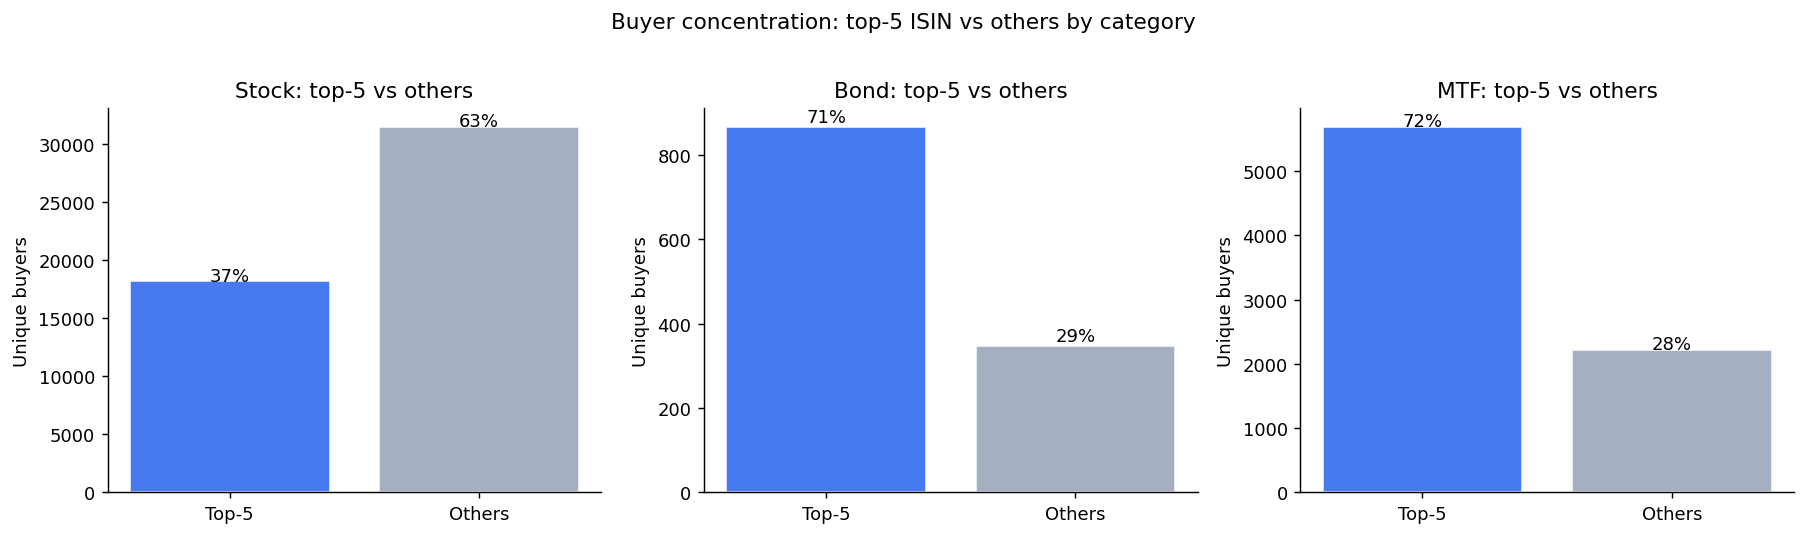

In [22]:
# 14.1 Топ-10 активов по каждой категории (popularity fallback)
for cat in ['Stock', 'Bond', 'MTF']:
    top = isin_stats[isin_stats['assetCategory'] == cat].head(10)
    print(f"\n  Top-10 {cat} по уник. покупателям:")
    print(top[['ISIN', 'n_buyers', 'n_transactions']].to_string(index=False))

# 14.2 Concentration: топ-5 vs остальные по категориям
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, cat in zip(axes, ['Stock', 'Bond', 'MTF']):
    data = isin_stats[isin_stats['assetCategory'] == cat].copy()
    data = data.sort_values('n_buyers', ascending=False)
    
    top5_buyers = data.head(5)['n_buyers'].sum()
    rest_buyers = data.iloc[5:]['n_buyers'].sum()
    
    ax.bar(['Top-5', 'Others'], [top5_buyers, rest_buyers],
           color=[BLUE, GREY], alpha=0.85, edgecolor='white')
    ax.set_title(f"{cat}: top-5 vs others")
    ax.set_ylabel("Unique buyers")
    total = top5_buyers + rest_buyers
    ax.text(0, top5_buyers + 10, f"{top5_buyers/total:.0%}", ha='center', fontsize=10)
    ax.text(1, rest_buyers + 10, f"{rest_buyers/total:.0%}", ha='center', fontsize=10)

plt.suptitle("Buyer concentration: top-5 ISIN vs others by category", y=1.02)
plt.tight_layout()
plt.savefig(EDA_DIR / "popularity_concentration_by_cat.png", bbox_inches="tight")
plt.show()

## 15. Итоговые выводы и параметры модели


In [23]:
# 15.1 Итоговая таблица ключевых параметров
print("═" * 70)
print("  ИТОГИ EDA — ключевые числа для архитектуры recommender")
print("═" * 70)

print("\n  [1] МАТРИЦА ВЗАИМОДЕЙСТВИЙ")
print(f"      Пользователей (train set): {n_users:,}")
print(f"      ISIN в покупках (train):  {n_items:,}")
print(f"      Глобальная плотность:     {density:.4%}")

print("\n  [2] COLD-START (warm клиенты, ≤60d)")
warm_lt3 = (hot_proxy_warm['n_unique_isin'] < 3).mean()
print(f"      < 3 уникальных ISIN:      {warm_lt3:.1%} клиентов → fallback")
warm_lt5 = (hot_proxy_warm['n_unique_isin'] < 5).mean()
print(f"      < 5 уникальных ISIN:      {warm_lt5:.1%} клиентов → граница ALS")

print("\n  [3] ITEM SUPPORT (порог надёжности эмбеддинга)")
gt10 = (isin_stats['n_buyers'] >= 10).sum()
print(f"      ISIN с ≥10 покупателями:  {gt10}/{n_items} ({gt10/n_items:.0%}) — ALS-eligible")
gt5  = (isin_stats['n_buyers'] >= 5).sum()
print(f"      ISIN с ≥5 покупателями:   {gt5}/{n_items} ({gt5/n_items:.0%}) — мягкий порог")

print("\n  [4] REPEAT-BUY (фильтр недавних покупок)")
lt30 = (repeat_gaps <= 30).mean()
print(f"      Repeat-buy в ≤30d:        {lt30:.1%} всех повторных покупок")
print(f"      → рекомендуемый EXCLUDE_RECENT_DAYS = 30")

print("\n  [5] LOO VALIDATION")
print(f"      Eligible (≥3 уник. ISIN, validation period): {len(eligible_val):,}")

print("\n  [6] HYPERPARAMETERS ALS")
print(f"      Рекомендуемый диапазон k: [8, 12, 16, 24, 32]")
print(f"      k=50 (из исходного плана) — избыточен при density={density:.2%}")

print("\n  [7] PORTFOLIO BOOST")
stock_only = (client_categories['has_stock'] & ~client_categories['has_bond'] & ~client_categories['has_mtf']).mean()
print(f"      Stock-only клиентов:      {stock_only:.1%} — для них буст Bond/MTF спорен")
print(f"      → Буст применять только если клиент имеет ≥2 разных категорий в истории")
print(f"        ИЛИ если клиент не покупал данную категорию в последние 365d")

print("\n  [8] GINI POPULARITY")
print(f"      Gini коэффициент: {gini:.3f} → {'высокая' if gini > 0.6 else 'умеренная'} концентрация")

══════════════════════════════════════════════════════════════════════
  ИТОГИ EDA — ключевые числа для архитектуры recommender
══════════════════════════════════════════════════════════════════════

  [1] МАТРИЦА ВЗАИМОДЕЙСТВИЙ
      Пользователей (train set): 22,905
      ISIN в покупках (train):  279
      Глобальная плотность:     0.9212%

  [2] COLD-START (warm клиенты, ≤60d)
      < 3 уникальных ISIN:      22.9% клиентов → fallback
      < 5 уникальных ISIN:      44.5% клиентов → граница ALS

  [3] ITEM SUPPORT (порог надёжности эмбеддинга)
      ISIN с ≥10 покупателями:  203/279 (73%) — ALS-eligible
      ISIN с ≥5 покупателями:   223/279 (80%) — мягкий порог

  [4] REPEAT-BUY (фильтр недавних покупок)
      Repeat-buy в ≤30d:        62.3% всех повторных покупок
      → рекомендуемый EXCLUDE_RECENT_DAYS = 30

  [5] LOO VALIDATION
      Eligible (≥3 уник. ISIN, validation period): 2,816

  [6] HYPERPARAMETERS ALS
      Рекомендуемый диапазон k: [8, 12, 16, 24, 32]
      k=50 (из 

In [24]:
# 15.2 Сохранение ключевых параметров в JSON для использования в config.py
summary = {
    "matrix": {
        "n_users_train": int(n_users),
        "n_items_train": int(n_items),
        "density_global": float(round(density, 6)),
        "gini_popularity": float(round(gini, 4)),
    },
    "cold_start": {
        "warm_pct_lt3_unique": float(round(warm_lt3, 3)),
        "warm_pct_lt5_unique": float(round(warm_lt5, 3)),
        "recommended_MIN_TX_REC": 3,
    },
    "item_support": {
        "isin_with_ge10_buyers": int(gt10),
        "isin_with_ge5_buyers": int(gt5),
        "recommended_MIN_ITEM_SUPPORT": 5,
    },
    "repeat_buy": {
        "repeat_rate_in_30d": float(round(lt30, 3)),
        "recommended_EXCLUDE_RECENT_DAYS": 30,
    },
    "als_k": {
        "recommended_grid": [8, 12, 16, 24, 32],
        "original_plan_k50": "избыточен",
    },
    "portfolio_boost": {
        "stock_only_fraction": float(round(stock_only, 3)),
        "recommendation": "применять только для клиентов с ≥1 категорией в истории или если кат. не покупалась 365d",
    },
    "lOO_validation": {
        "eligible_clients": int(len(eligible_val)),
        "MIN_TX_EVAL": 3,
    }
}

with open(EDA_DIR / "eda_recommender_summary.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Параметры сохранены в outputs/eda_recommender/eda_recommender_summary.json")
print(json.dumps(summary, indent=2, ensure_ascii=False))

Параметры сохранены в outputs/eda_recommender/eda_recommender_summary.json
{
  "matrix": {
    "n_users_train": 22905,
    "n_items_train": 279,
    "density_global": 0.009212,
    "gini_popularity": 0.7995
  },
  "cold_start": {
    "warm_pct_lt3_unique": 0.229,
    "warm_pct_lt5_unique": 0.445,
    "recommended_MIN_TX_REC": 3
  },
  "item_support": {
    "isin_with_ge10_buyers": 203,
    "isin_with_ge5_buyers": 223,
    "recommended_MIN_ITEM_SUPPORT": 5
  },
  "repeat_buy": {
    "repeat_rate_in_30d": 0.623,
    "recommended_EXCLUDE_RECENT_DAYS": 30
  },
  "als_k": {
    "recommended_grid": [
      8,
      12,
      16,
      24,
      32
    ],
    "original_plan_k50": "избыточен"
  },
  "portfolio_boost": {
    "stock_only_fraction": 0.697,
    "recommendation": "применять только для клиентов с ≥1 категорией в истории или если кат. не покупалась 365d"
  },
  "lOO_validation": {
    "eligible_clients": 2816,
    "MIN_TX_EVAL": 3
  }
}
